# 04 - Modélisation

On entraîne un GradientBoosting avec GridSearchCV et on évalue ses performances.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

import json
import mlflow
import json
import mlflow.sklearn

load_dotenv("../.env")

BUCKET = os.getenv("S3_BUCKET")
PROC = f"s3://{BUCKET}/processed"

STORAGE = {
    "key": os.getenv("AWS_ACCESS_KEY_ID"),
    "secret": os.getenv("AWS_SECRET_ACCESS_KEY"),
    "client_kwargs": {"region_name": os.getenv("AWS_REGION")}
}

MLFLOW_URI = os.getenv("MLFLOW_TRACKING_URI")
MLFLOW_EXPERIMENT = os.getenv("MLFLOW_EXPERIMENT_NAME", "cdm2026_predictions")

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

print(f"bucket: {BUCKET}")
print(f"MLflow: {MLFLOW_URI} | exp: {MLFLOW_EXPERIMENT}")

bucket: fifa-wc-predict-915328198414-eu-west-3-an
MLflow: https://remiince-mlflow-server.hf.space | exp: cdm2026_predictionsx


## 1. Chargement des données

In [2]:
df = pd.read_csv(f"{PROC}/dataset_features.csv", storage_options=STORAGE)

FEATURES = [
    "rank_dif",
    "goals_dif", "goals_dif_l5",
    "goals_suf_dif", "goals_suf_dif_l5",
    "goals_per_ranking_dif",
    "dif_rank_agst", "dif_rank_agst_l5",
    "dif_points_rank", "dif_points_rank_l5",
    "is_friendly"
]

X = df[FEATURES]
y = df["target"]

print(f"Dataset : {X.shape[0]} matchs, {X.shape[1]} features")
print(f"Classes : {y.value_counts().to_dict()}")

Dataset : 3019 matchs, 11 features
Classes : {1: 1625, 0: 1394}


## 2. Train / Test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

print(f"Train : {len(X_train)} matchs")
print(f"Test  : {len(X_test)} matchs")

Train : 2415 matchs
Test  : 604 matchs


## 3. Entraînement — GradientBoosting

In [4]:
gb_params = {
    "learning_rate": [0.01, 0.1, 0.5],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [3, 5],
    "max_depth": [3, 5, 10],
    "max_features": ["sqrt"],
    "n_estimators": [100, 200]
}

with mlflow.start_run(run_name="gradient_boosting_gridsearch") as run:
    gb_cv = GridSearchCV(
        GradientBoostingClassifier(random_state=5),
        gb_params, cv=3, n_jobs=-1, scoring="roc_auc"
    )
    gb_cv.fit(X_train, y_train)
    gb = gb_cv.best_estimator_

    auc_train = roc_auc_score(y_train, gb.predict_proba(X_train)[:, 1])
    auc_test = roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1])

    mlflow.log_params(gb_cv.best_params_)
    mlflow.log_param("cv_folds", 3)
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_param("test_size", len(X_test))
    mlflow.log_metric("auc_train", auc_train)
    mlflow.log_metric("auc_test", auc_test)
    mlflow.log_metric("auc_gap", auc_train - auc_test)

    # Sauvegarde du modèle dans NeonDB
    import pickle, psycopg2
    run_id = run.info.run_id
    model_bytes = pickle.dumps(gb)

    conn = psycopg2.connect(os.getenv("NEON_DATABASE_URL"))
    with conn:
        with conn.cursor() as cur:
            cur.execute("""
                CREATE TABLE IF NOT EXISTS model_artifacts (
                    id SERIAL PRIMARY KEY,
                    run_id TEXT NOT NULL,
                    model_name TEXT NOT NULL,
                    model_data BYTEA NOT NULL,
                    auc_test FLOAT,
                    params JSONB,
                    created_at TIMESTAMPTZ DEFAULT NOW()
                )
            """)
            cur.execute(
                """INSERT INTO model_artifacts (run_id, model_name, model_data, auc_test, params)
                   VALUES (%s, %s, %s, %s, %s)""",
                (run_id, "gradient_boosting", psycopg2.Binary(model_bytes),
                 auc_test, json.dumps(gb_cv.best_params_))
            )
    conn.close()

    mlflow.set_tag("neondb_stored", "true")
    mlflow.set_tag("model_name", "gradient_boosting")

    print(f"GB — train: {auc_train:.3f} | test: {auc_test:.3f}")
    print(f"params: {gb_cv.best_params_}")
    print(f"MLflow run_id: {run_id}")
    print("Modèle sauvegardé dans NeonDB ✓")

GB — train: 0.865 | test: 0.774
params: {'learning_rate': 0.01, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 100}
MLflow run_id: 161089ee90ca403da951ffad4671dede
Modèle sauvegardé dans NeonDB ✓
🏃 View run gradient_boosting_gridsearch at: https://remiince-mlflow-server.hf.space/#/experiments/1/runs/161089ee90ca403da951ffad4671dede
🧪 View experiment at: https://remiince-mlflow-server.hf.space/#/experiments/1


## 5. Évaluation du modèle

In [5]:
print(f"GB — train: {auc_train:.3f} | test: {auc_test:.3f} (gap={auc_train - auc_test:.3f})")

GB — train: 0.865 | test: 0.774 (gap=0.091)


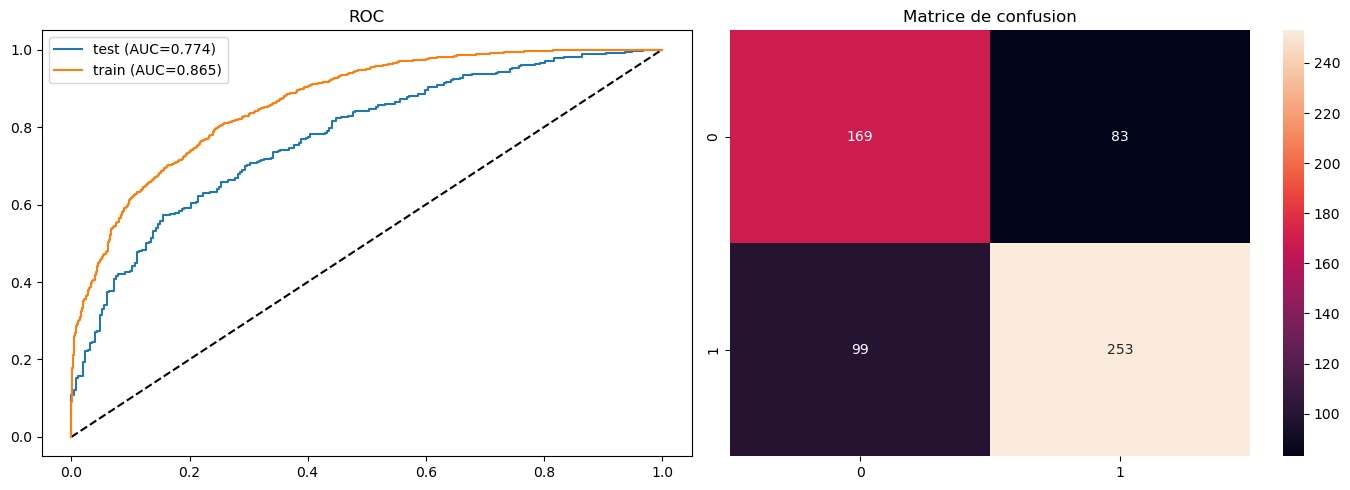

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr_test, tpr_test, _ = roc_curve(y_test, gb.predict_proba(X_test)[:, 1])
fpr_train, tpr_train, _ = roc_curve(y_train, gb.predict_proba(X_train)[:, 1])

axes[0].plot([0, 1], [0, 1], "k--")
axes[0].plot(fpr_test, tpr_test, label=f"test (AUC={auc_test:.3f})")
axes[0].plot(fpr_train, tpr_train, label=f"train (AUC={auc_train:.3f})")
axes[0].set_title("ROC")
axes[0].legend()

cm = confusion_matrix(y_test, gb.predict(X_test))
sns.heatmap(cm, annot=True, fmt="d", ax=axes[1])
axes[1].set_title("Matrice de confusion")

plt.tight_layout()
plt.show()

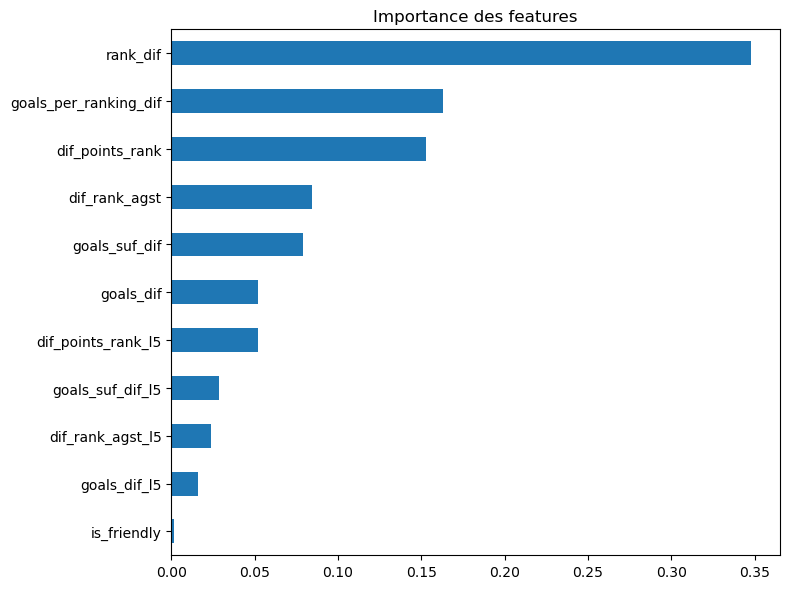

In [7]:
# Importance des features
importances = pd.Series(gb.feature_importances_, index=FEATURES).sort_values(ascending=True)

importances.plot(kind="barh", figsize=(8, 6))
plt.title("Importance des features")
plt.tight_layout()
plt.show()